# SQL E-commerce Revenue Analysis

This notebook analyzes user purchase behavior and revenue patterns using an e-commerce dataset.

The analysis focuses on three key questions:
1. How do new and returning users differ in revenue contribution?
2. Which product categories drive the most revenue?
3. How does price segmentation influence revenue generation?

In [1]:
## 1. Import Libraries and Load Data 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_user = pd.read_csv("New vs Returning.csv")
df_category = pd.read_csv("Category Analysis.csv")
df_price = pd.read_csv("Price Analysis Query Result.csv")

This step is to load the pre-aggregated analysis results for each section of the project.

- `df_user`: comparison of new vs returning users
- `df_category`: category-level revenue and purchase behavior
- `df_price`: price-segment revenue analysis

These datasets are used directly for visualization and interpretation.

## 2. New vs Returning Users
### Objective

To compare revenue contribution and purchasing behavior between new and returning users.

### Data Overview

This dataset contains aggregated metrics for new and returning users, including total orders and total revenue.

In [3]:
df_user.head()

,user_type,user_count,order_count,revenue,avg_price_per_item
0,New,80106,80106,6.907690e+06,59.452187
1,Returning,29970,45165,3.921182e+06,59.745888


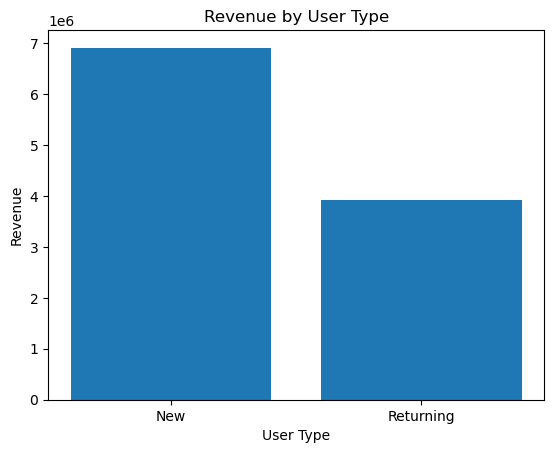

In [4]:
plt.figure()

plt.bar(df_user["user_type"], df_user["revenue"])

plt.xlabel("User Type")
plt.ylabel("Revenue")
plt.title("Revenue by User Type")

plt.show()

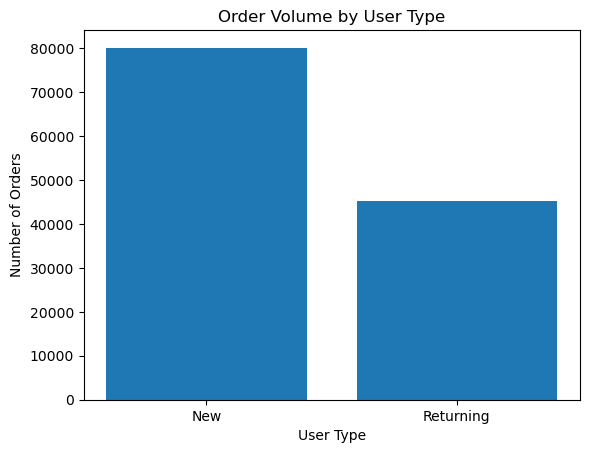

In [5]:
plt.figure()

plt.bar(df_user["user_type"], df_user["order_count"])

plt.xlabel("User Type")
plt.ylabel("Number of Orders")
plt.title("Order Volume by User Type")

plt.show()

### Insight

Although new users generate higher total revenue due to their larger population, returning users place significantly more orders per user.

This indicates that revenue growth is primarily driven by purchase frequency rather than spending per transaction.

Returning users contribute more efficiently to revenue on a per-user basis.

## 3. Category Analysis

### Objective

To identify which product categories drive revenue and how purchasing behavior differs across categories.

### Data Overview

This dataset contains aggregated metrics by product category, including total purchases and total revenue.

In [6]:
df_category.head()

,category,purchase_count,order_count,revenue,avg_price
0,Outerwear & Coats,9017,8813,1.301914e+06,144.384343
1,Jeans,12774,12347,1.243124e+06,97.316774
2,Sweaters,11107,10804,8.360638e+05,75.273596
3,Suits & Sport Coats,5167,5030,6.586818e+05,127.478585
4,Swim,11382,11069,6.464580e+05,56.796524


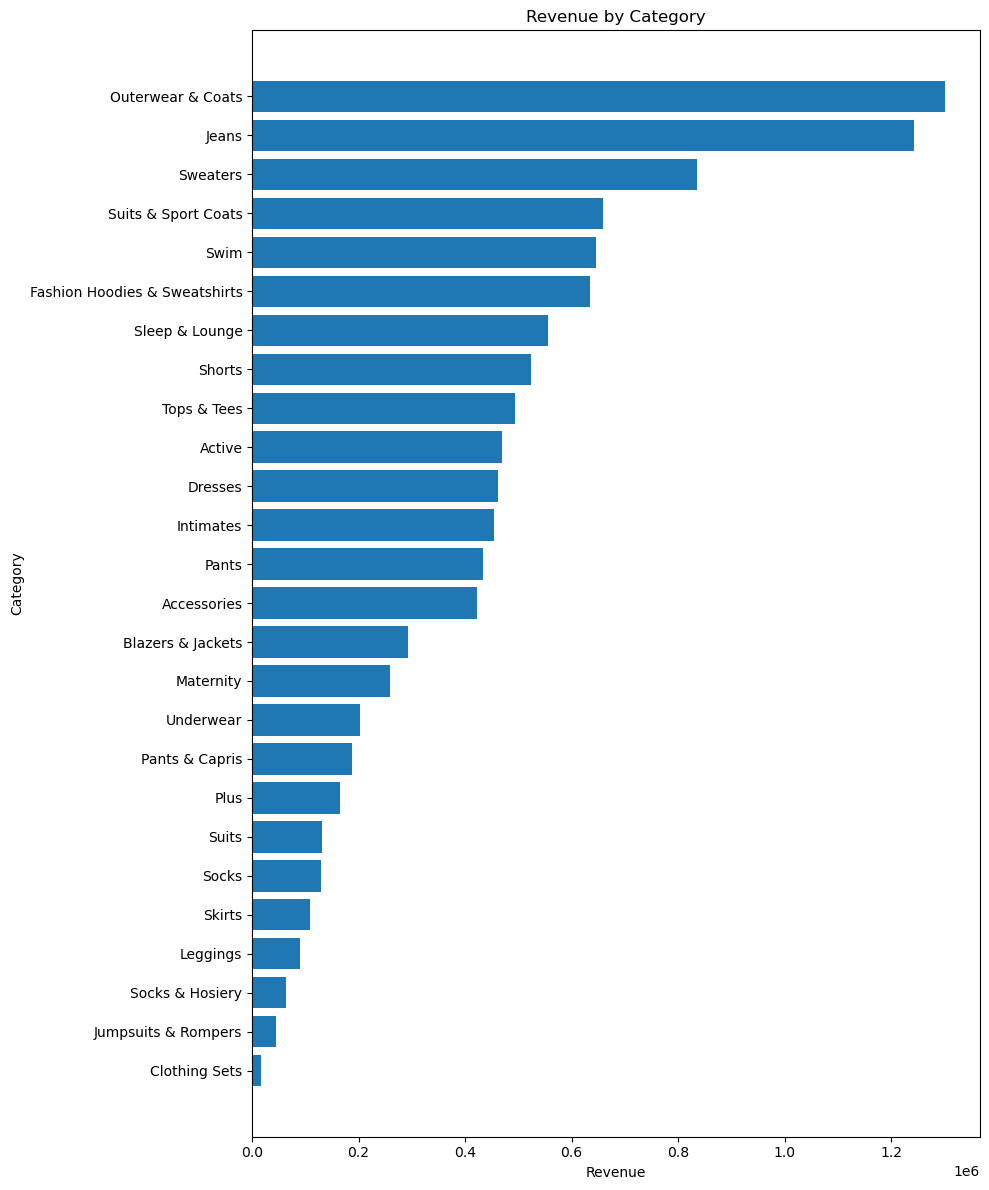

In [11]:
# 1. revenue 기준 내림차순 정렬
df_sorted = df_category.sort_values(by="revenue", ascending=True)

# 2. 그래프의 가독성을 높이기 위한 작업
plt.figure(figsize=(10, 12))

# 3. 그래프
plt.barh(df_sorted["category"], df_sorted["revenue"])

# 4. 라벨 / 타이틀
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.title("Revenue by Category")

# 5. 레이아웃 자동 조정
plt.tight_layout()

plt.show()

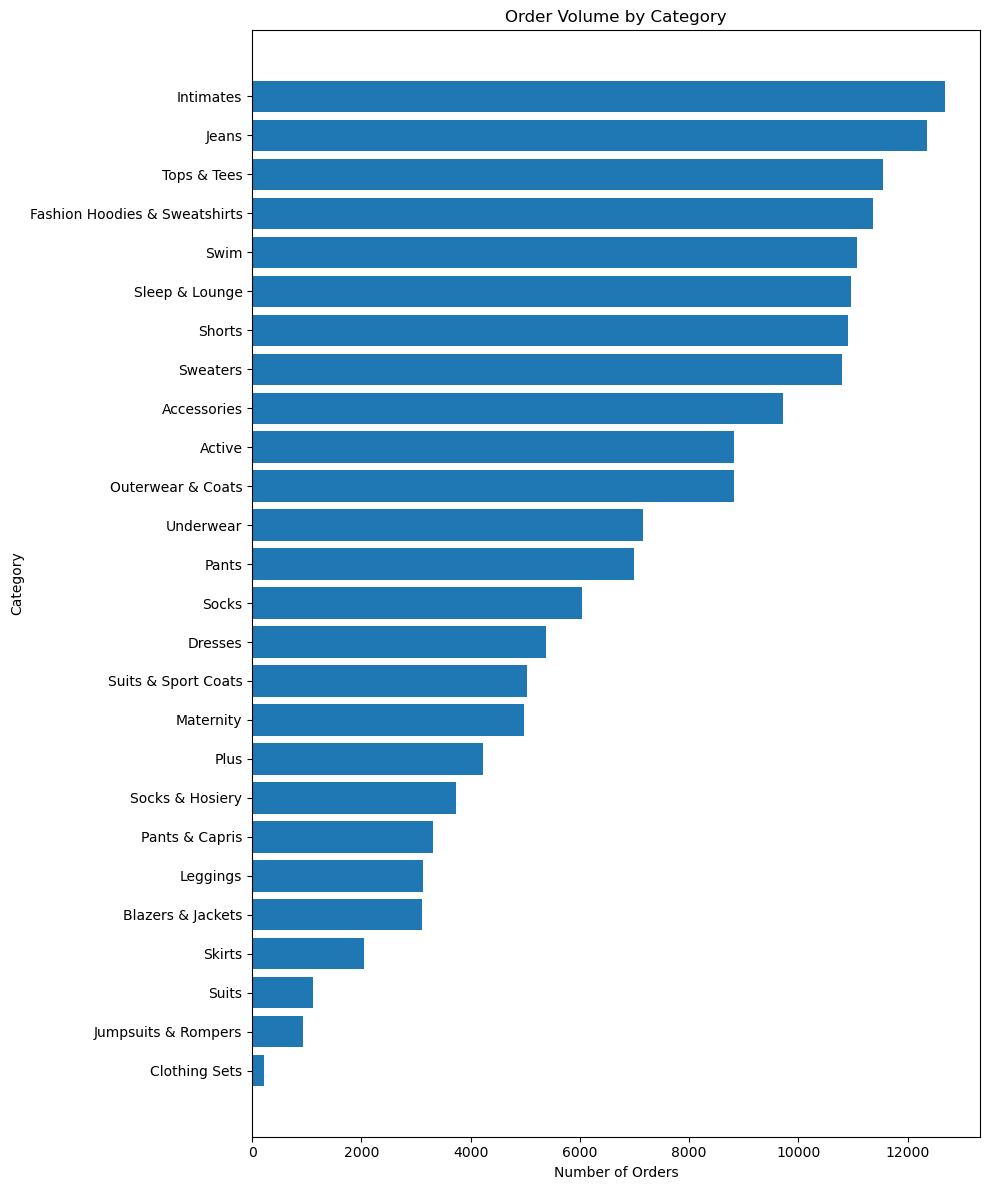

In [13]:
# 1. order 기준 정렬 (내림차순)
df_sorted_order = df_category.sort_values(by="order_count", ascending=True)

# 2. 그래프의 가독성을 높이기 위한 작업
plt.figure(figsize=(10, 12))

# 3. 그래프
plt.barh(df_sorted_order["category"], df_sorted_order["order_count"])

# 4. 라벨
plt.xlabel("Number of Orders")
plt.ylabel("Category")
plt.title("Order Volume by Category")

# 5. 레이아웃
plt.tight_layout()

plt.show()

### Insight

Revenue is not driven by purchase volume alone.

While categories such as Intimates and Jeans generate high order volumes, Outerwear & Coats produce the highest revenue with relatively fewer purchases.

This indicates that higher-priced categories contribute disproportionately to total revenue, emphasizing the importance of value over volume.

## 4. Price Analysis

### Objective

To analyze how different price segments influence purchasing behavior and revenue generation.

### Data Overview

This dataset contains aggregated metrics by price segment, including total purchases and total revenue.

In [14]:
df_price.head()

,price_band,purchase_count,order_count,revenue,avg_price
0,High,36790,33661,5.624792e+06,152.889166
1,Mid,77772,65058,3.913252e+06,50.316978
2,Low,67258,57467,1.290828e+06,19.192186


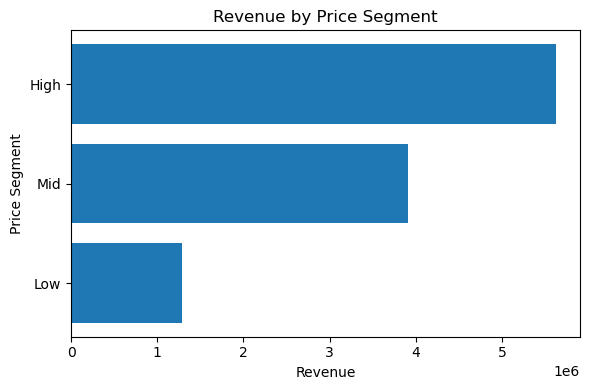

In [15]:
# revenue 기준 정렬
df_price_sorted = df_price.sort_values(by="revenue", ascending=True)

plt.figure(figsize=(6, 4))

plt.barh(df_price_sorted["price_band"], df_price_sorted["revenue"])

plt.xlabel("Revenue")
plt.ylabel("Price Segment")
plt.title("Revenue by Price Segment")

plt.tight_layout()
plt.show()

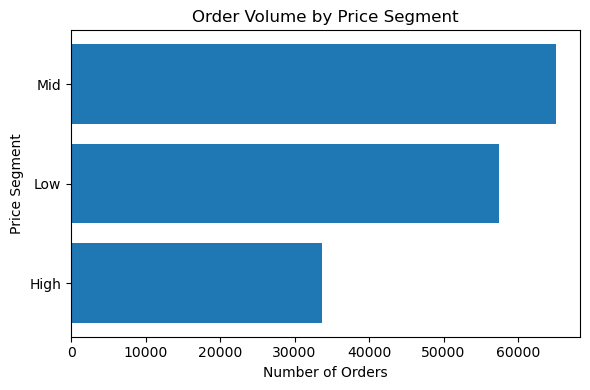

In [16]:
# order 기준 정렬
df_price_sorted_order = df_price.sort_values(by="order_count", ascending=True)

plt.figure(figsize=(6, 4))

plt.barh(df_price_sorted_order["price_band"], df_price_sorted_order["order_count"])

plt.xlabel("Number of Orders")
plt.ylabel("Price Segment")
plt.title("Order Volume by Price Segment")

plt.tight_layout()
plt.show()

### Insight

The pricing structure reveals a clear pattern: high-priced items generate the highest revenue despite having the lowest number of purchases.

For example, the high-price segment generates approximately 5.6M in revenue from 33K purchases, while the low-price segment generates only 1.3M from 57K purchases.

This indicates that revenue is significantly more sensitive to price than to transaction volume.

High-value purchases play a dominant role in overall revenue generation.

## Conclusion

This analysis demonstrates that revenue growth is not driven by transaction volume alone.

Across all analyses, two key factors consistently emerge:

- Purchase frequency (Returning users)
- Price (High-value products)

Returning users contribute more through repeated purchases, while high-priced products generate disproportionate revenue.

These findings suggest that the most effective growth strategy is not acquiring more users, but maximizing the value of existing users through retention and high-value offerings.